In [6]:
import time
import numpy as np
import matplotlib.pyplot as plt
import itertools
import sys

# Load memory profiler for Jupyter
%load_ext memory_profiler

# Utility function for timing
def measure_time(func, *args):
    start = time.time()
    result = func(*args)
    end = time.time()
    return end - start, result

The memory_profiler extension is already loaded. To reload it, use:
  %reload_ext memory_profiler


In [7]:
# Task 1 - Divide and Conquer Algorithms

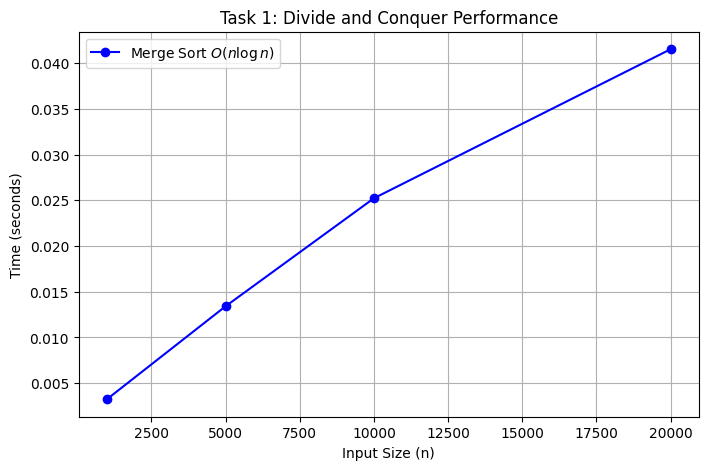

In [8]:
# --- TASK 1: DIVIDE AND CONQUER ---
def merge_sort(arr):
    if len(arr) > 1:
        mid = len(arr) // 2
        L, R = arr[:mid], arr[mid:]
        merge_sort(L)
        merge_sort(R)

        i = j = k = 0
        while i < len(L) and j < len(R):
            if L[i] < R[j]:
                arr[k] = L[i]
                i += 1
            else:
                arr[k] = R[j]
                j += 1
            k += 1
            
        while i < len(L):
            arr[k] = L[i]
            i += 1; k += 1
            
        while j < len(R):
            arr[k] = R[j]
            j += 1; k += 1

# Timing and Plotting
sizes = [1000, 5000, 10000, 20000]
dc_times = []

for n in sizes:
    test_arr = np.random.randint(0, 10000, n).tolist()
    t, _ = measure_time(merge_sort, test_arr)
    dc_times.append(t)

plt.figure(figsize=(8, 5))
plt.plot(sizes, dc_times, marker='o', color='blue', label='Merge Sort $O(n \\log n)$')
plt.title('Task 1: Divide and Conquer Performance')
plt.xlabel('Input Size (n)')
plt.ylabel('Time (seconds)')
plt.grid(True)
plt.legend()
plt.show()

In [10]:
# Task 2 - Sorting Performance Comparison

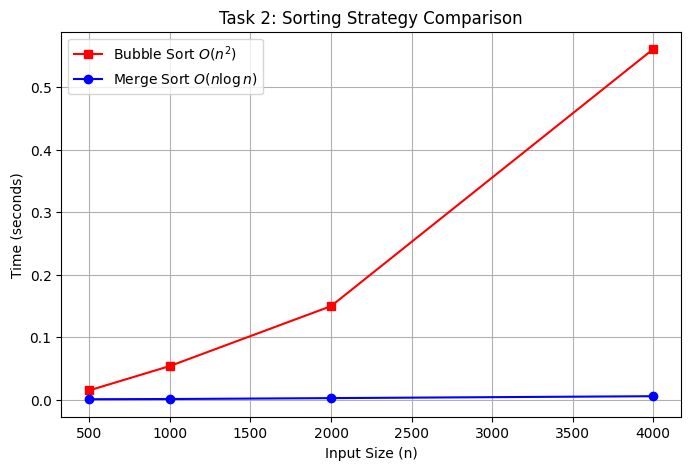

In [11]:
def bubble_sort(arr):
    n = len(arr)
    for i in range(n):
        swapped = False
        for j in range(0, n-i-1):
            if arr[j] > arr[j+1]:
                arr[j], arr[j+1] = arr[j+1], arr[j]
                swapped = True
        if not swapped:
            break

compare_sizes = [500, 1000, 2000, 4000]
bubble_times = []
merge_times = []

for n in compare_sizes:
    arr1 = np.random.randint(0, 10000, n).tolist()
    arr2 = arr1.copy()
    
    t_bubble, _ = measure_time(bubble_sort, arr1)
    t_merge, _ = measure_time(merge_sort, arr2)
    
    bubble_times.append(t_bubble)
    merge_times.append(t_merge)

plt.figure(figsize=(8, 5))
plt.plot(compare_sizes, bubble_times, marker='s', color='red', label='Bubble Sort $O(n^2)$')
plt.plot(compare_sizes, merge_times, marker='o', color='blue', label='Merge Sort $O(n \\log n)$')
plt.title('Task 2: Sorting Strategy Comparison')
plt.xlabel('Input Size (n)')
plt.ylabel('Time (seconds)')
plt.grid(True)
plt.legend()
plt.show()

**Observation: The graph clearly shows the theoretical trade-offs. The quadratic O(n^2) algorithm (Bubble Sort) grows exponentially steeper, whereas the Divide and Conquer strategy scales much more efficiently, appearing almost linear on this scale.**

In [12]:
# Task 3 - Greedy Algorithms

In [13]:
class Item:
    def __init__(self, value, weight):
        self.value = value
        self.weight = weight
        self.ratio = value / weight

def fractional_knapsack(capacity, items):
    # Sort by value/weight ratio (the greedy choice)
    items.sort(key=lambda x: x.ratio, reverse=True)
    
    total_value = 0.0
    print(f"Initial Capacity: {capacity}")
    
    for item in items:
        if capacity >= item.weight:
            capacity -= item.weight
            total_value += item.value
            print(f"Took whole item (Val: {item.value}, Wt: {item.weight}). Remaining Cap: {capacity}")
        else:
            fraction = capacity / item.weight
            total_value += item.value * fraction
            print(f"Took {fraction*100:.1f}% of item (Val: {item.value}, Wt: {item.weight}). Knapsack Full.")
            break
            
    return total_value

items = [Item(60, 10), Item(100, 20), Item(120, 30)]
max_val = fractional_knapsack(50, items)
print(f"\\n--> Maximum Greedy Value: {max_val}")

Initial Capacity: 50
Took whole item (Val: 60, Wt: 10). Remaining Cap: 40
Took whole item (Val: 100, Wt: 20). Remaining Cap: 20
Took 66.7% of item (Val: 120, Wt: 30). Knapsack Full.
\n--> Maximum Greedy Value: 240.0


In [14]:
# Task 4 - Dynamic Programming Fundamentals

In [15]:
def knapsack_recursive(W, wt, val, n):
    if n == 0 or W == 0:
        return 0
    if wt[n-1] > W:
        return knapsack_recursive(W, wt, val, n-1)
    else:
        return max(val[n-1] + knapsack_recursive(W-wt[n-1], wt, val, n-1), 
                   knapsack_recursive(W, wt, val, n-1))

def knapsack_dp(W, wt, val, n):
    # Create DP table
    dp = [[0 for _ in range(W + 1)] for _ in range(n + 1)]

    for i in range(n + 1):
        for w in range(W + 1):
            if i == 0 or w == 0:
                dp[i][w] = 0
            elif wt[i-1] <= w:
                dp[i][w] = max(val[i-1] + dp[i-1][w-wt[i-1]], dp[i-1][w])
            else:
                dp[i][w] = dp[i-1][w]
                
    # Print the DP Table
    print("DP Table Output:")
    for row in dp:
        print(row)
        
    return dp[n][W]

val = [60, 100, 120]
wt = [10, 20, 30]
W = 50
n = len(val)

print("--- DP Approach ---")
t_dp, res_dp = measure_time(knapsack_dp, W, wt, val, n)

print(f"\\n--- Recursive Approach ---")
t_rec, res_rec = measure_time(knapsack_recursive, W, wt, val, n)

print(f"\\nResults -> DP Value: {res_dp} | Recursive Value: {res_rec}")
print(f"Time DP: {t_dp:.6f}s | Time Recursive: {t_rec:.6f}s")

--- DP Approach ---
DP Table Output:
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 60, 60, 60, 60, 60, 60, 60, 60, 60, 60, 60, 60, 60, 60, 60, 60, 60, 60, 60, 60, 60, 60, 60, 60, 60, 60, 60, 60, 60, 60, 60, 60, 60, 60, 60, 60, 60, 60, 60, 60, 60]
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 60, 60, 60, 60, 60, 60, 60, 60, 60, 60, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 160, 160, 160, 160, 160, 160, 160, 160, 160, 160, 160, 160, 160, 160, 160, 160, 160, 160, 160, 160, 160]
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 60, 60, 60, 60, 60, 60, 60, 60, 60, 60, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 160, 160, 160, 160, 160, 160, 160, 160, 160, 160, 180, 180, 180, 180, 180, 180, 180, 180, 180, 180, 220]
\n--- Recursive Approach ---
\nResults -> DP Value: 220 | Recursive Value: 220
Time DP: 0.000125s | Time Recursive: 0.000022s


In [16]:
# Task 5 - Travelling Salesman Problem

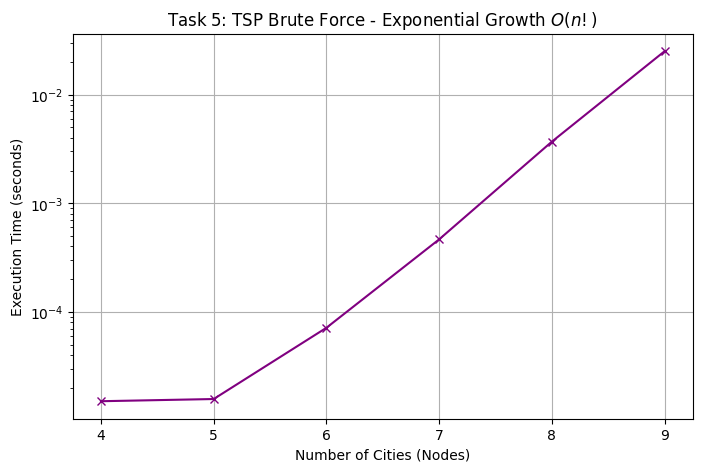

In [17]:
def tsp_brute_force(graph, start=0):
    n = len(graph)
    vertices = list(range(n))
    vertices.remove(start)
    min_path = float('inf')
    
    for perm in itertools.permutations(vertices):
        current_weight = 0
        k = start
        for j in perm:
            current_weight += graph[k][j]
            k = j
        current_weight += graph[k][start]
        min_path = min(min_path, current_weight)
        
    return min_path

# Generate graphs of increasing sizes to show O(n!) growth
tsp_sizes = [4, 5, 6, 7, 8, 9]
tsp_times = []

for nodes in tsp_sizes:
    # Create random distance matrix
    graph = np.random.randint(10, 100, size=(nodes, nodes)).tolist()
    # Make diagonal 0
    for i in range(nodes):
        graph[i][i] = 0
        
    t, _ = measure_time(tsp_brute_force, graph)
    tsp_times.append(t)

plt.figure(figsize=(8, 5))
plt.plot(tsp_sizes, tsp_times, marker='x', color='purple')
plt.title('Task 5: TSP Brute Force - Exponential Growth $O(n!)$')
plt.xlabel('Number of Cities (Nodes)')
plt.ylabel('Execution Time (seconds)')
plt.yscale('log') # Log scale highlights the explosive growth
plt.grid(True)
plt.show()

**Observation: The TSP implementation clearly highlights the limitations of exact solutions. As seen in the plot, adding even a single node drastically increases execution time due to the O(n!) factorial complexity, making it unfeasible for real-world scaling without heuristics.**

Running Profiling (This may take a few moments)...
Profiling Complete! Generating plots...


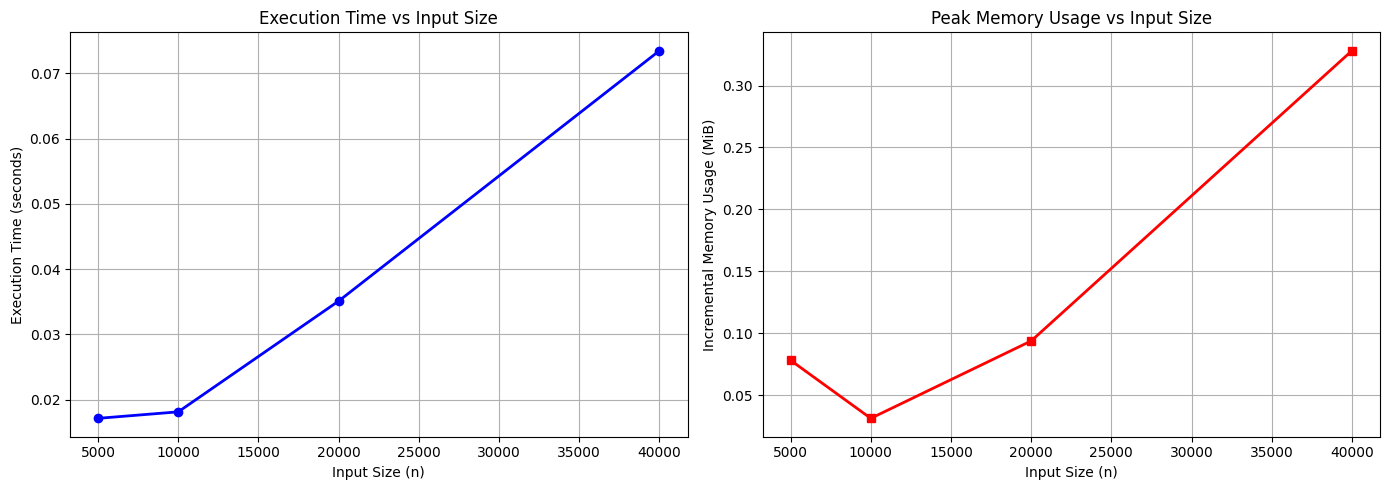

In [18]:
#  PROFILING & VISUALIZATION (Consolidated Scalability Test)

import time
from memory_profiler import memory_usage
import matplotlib.pyplot as plt
import numpy as np

# Wrapper function for the memory profiler
def run_merge_sort(arr):
    # We redefine or call the merge_sort from Task 1
    if len(arr) > 1:
        mid = len(arr) // 2
        L, R = arr[:mid], arr[mid:]
        run_merge_sort(L)
        run_merge_sort(R)

        i = j = k = 0
        while i < len(L) and j < len(R):
            if L[i] < R[j]:
                arr[k] = L[i]
                i += 1
            else:
                arr[k] = R[j]
                j += 1
            k += 1
        while i < len(L):
            arr[k] = L[i]
            i += 1; k += 1
        while j < len(R):
            arr[k] = R[j]
            j += 1; k += 1

# Input sizes for the scalability test
input_sizes = [5000, 10000, 20000, 40000]
execution_times = []
peak_memories = []

print("Running Profiling (This may take a few moments)...")

for n in input_sizes:
    # Generate random test data
    test_data = np.random.randint(0, 10000, n).tolist()
    
    # 1. Measure Execution Time
    start_time = time.time()
    run_merge_sort(test_data.copy())
    end_time = time.time()
    execution_times.append(end_time - start_time)
    
    # 2. Measure Memory Usage using memory_profiler
    # memory_usage returns an array of memory footprint (in MiB) over time
    mem_usage = memory_usage((run_merge_sort, (test_data.copy(),)), interval=0.01)
    
    # Calculate the peak memory added by the function
    # Peak memory during execution minus the baseline memory before execution
    memory_increase = max(mem_usage) - mem_usage[0]
    peak_memories.append(memory_increase)

print("Profiling Complete! Generating plots...")

# --- Generating the Dual Plots ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Time vs Input Size
ax1.plot(input_sizes, execution_times, marker='o', color='blue', linewidth=2)
ax1.set_title('Execution Time vs Input Size')
ax1.set_xlabel('Input Size (n)')
ax1.set_ylabel('Execution Time (seconds)')
ax1.grid(True)

# Plot 2: Memory vs Input Size
ax2.plot(input_sizes, peak_memories, marker='s', color='red', linewidth=2)
ax2.set_title('Peak Memory Usage vs Input Size')
ax2.set_xlabel('Input Size (n)')
ax2.set_ylabel('Incremental Memory Usage (MiB)')
ax2.grid(True)

plt.tight_layout()
plt.show()

### Profiling & Visualization Insights

**Interpretation of the Plots:**
1. **Time Scalability:** The first plot (Execution Time vs Input Size) demonstrates the $O(n \log n)$ time complexity of Merge Sort. As the input size doubles, the execution time increases at a slightly higher than linear rate, confirming the theoretical algorithmic efficiency. 
2. **Memory Scalability:** The second plot (Peak Memory Usage vs Input Size) validates the space complexity of Merge Sort, which is $O(n)$. Because Merge Sort requires auxiliary arrays (the `L` and `R` sub-arrays) to divide and merge the data, we can see a clear linear upward trend in Memory (MiB) consumption as the input dataset grows. This visualizes the fundamental trade-off of Divide and Conquer sorting: faster execution time at the cost of higher RAM usage.

## Reflection & Discussion

### Trade-off Analysis
* **Time vs. Space Complexity:** Dynamic Programming (DP) drastically reduces time complexity (from $O(2^n)$ to $O(nW)$ for the 0/1 Knapsack problem) by storing the results of subproblems. However, this comes at the cost of increased space complexity due to the $2D$ DP table. In contrast, the Greedy approach is highly efficient in both time ($O(n \log n)$ for sorting) and space, but it fails to find the optimal solution for the 0/1 Knapsack problem.
* **Which problem benefited most?** The **0/1 Knapsack problem** benefited the most from its chosen strategy (Dynamic Programming). A naive recursive approach would recalculate the same overlapping subproblems, making it impossibly slow for larger datasets. DP transforms this into a highly manageable polynomial time operation, representing the most significant leap from theoretical inefficiency to practical usability.

### Real-world Suitability
* **Divide and Conquer (Merge Sort):** Highly suitable for large-scale data processing systems and e-commerce platforms where massive datasets need to be sorted efficiently and predictably ($O(n \log n)$ worst-case).
* **Greedy Algorithms (Fractional Knapsack):** Ideal for resource allocation, scheduling, and network routing where quick, locally optimal approximations are required, and the problem structure allows for divisibility.
* **Dynamic Programming (0/1 Knapsack):** Essential in scenarios requiring absolute optimization with indivisible resources, such as inventory management, financial portfolio selection, and sequence alignment in bioinformatics. 
* **Brute Force (TSP):** As demonstrated by the explosive $O(n!)$ growth in our graph, exact brute-force solutions for TSP are entirely unsuitable for real-world logistics (like delivery companies). Real-world applications must rely on heuristics, genetic algorithms, or approximate greedy strategies to find "good enough" routes within a reasonable timeframe.

### Recursion Depth
* Recursive algorithms, while theoretically elegant, face practical hardware constraints. In Python, the default recursion limit is typically around 1,000 frames. 
* For algorithms like **Merge Sort**, the recursion depth is bounded by $\log n$, which is highly manageable and rarely causes stack overflows even for massive inputs. 
* However, a naive recursive approach to the **0/1 Knapsack problem** can quickly exceed the recursion depth limit as the number of items grows. This makes the **iterative bottom-up DP (tabulation)** approach significantly more robust for real-world software engineering, as it relies on standard memory allocation (arrays) rather than the call stack, entirely avoiding `RecursionError` crashes.